In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [ ]:
import matplotlib.pyplot as plt

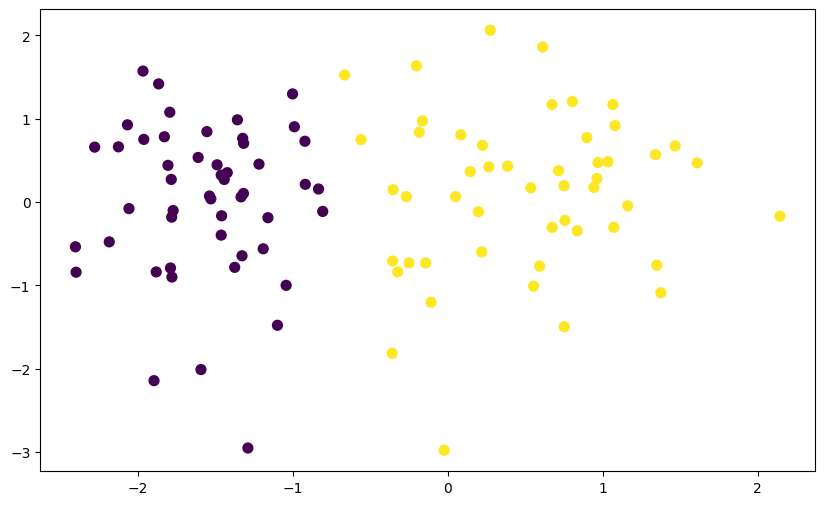

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,s=50)

In [ ]:
import numpy as np

class My_Per:
    def __init__(self, num_input, lr=0.01):
        self.weights = np.random.randn(num_input) * 0.01
        self.bias = 0.0
        self.lr = lr

    def step_func(self, value):
        return 1 if value > 0 else 0

    def predict(self, x):
        # Calculation: z = w · x + b
        linear_output = np.dot(x, self.weights) + self.bias
        return self.step_func(linear_output)

    def train(self, X, Y, epochs=25):
        errors_per_epoch = []

        for epoch in range(epochs):
            total_error = 0
            for x, y in zip(X, Y):
                # 1. Predict for the single sample 'x'
                y_pred = self.predict(x)

                # 2. Calculate error
                error = y - y_pred

                # 3. Update weights and bias: Δw = lr * (y - y_pred) * x
                if error != 0:
                    self.weights += self.lr * error * x
                    self.bias += self.lr * error
                    total_error += abs(error)

            errors_per_epoch.append(total_error)


        return errors_per_epoch

In [ ]:
model = My_Per(num_input=2, lr=0.1)

errors = model.train(X, y, epochs=50)

print(f"Final Weights: {model.weights}")
print(f"Final Bias: {model.bias}")

Final Weights: [0.26719232 0.00814356]
Final Bias: 0.2


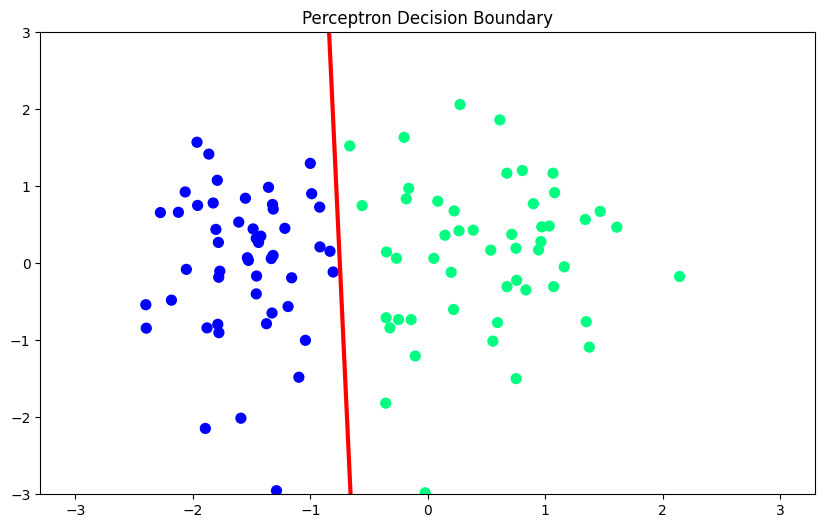

In [ ]:
# Calculate the slope (m) and intercept (c) for the boundary line
m = -(model.weights[0] / model.weights[1])
c = -(model.bias / model.weights[1])

# Create the line points
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + c

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter') # Original data
plt.plot(x_input, y_input, color='red', linewidth=3)    # The Perceptron's line
plt.ylim(-3, 3) # Adjust based on your data spread
plt.title("Perceptron Decision Boundary")
plt.show()

In [ ]:
df = pd.DataFrame(
    [[8, 8, 1],
     [7, 9, 1],
     [6, 10, 0],
     [5, 5, 0]],
    columns=['cgpa', 'profile_score', 'placed']
)

In [ ]:
df

,cgpa,profile_score,placed
0,8,8,1
1,7,9,1
2,6,10,0
3,5,5,0


In [ ]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

In [ ]:
def initialize_parameters(layer_dims):
    parameters = {}
    L = len(layer_dims)
    for l in range(1,L):
      parameters['w'+str(l)] = np.random.randn(layer_dims[l],layer_dims[l-1])*0.1
      parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

    return parameters


In [ ]:
initialize_parameters([2,2,1])


{'w1': array([[-0.02731211,  0.28449759],
        [-0.2105494 , -0.11196044]]),
 'b1': array([[0.],
        [0.]]),
 'w2': array([[ 0.03687096, -0.20783221]]),
 'b2': array([[0.]])}

In [ ]:
def linear_forward(A_prev,w,b):
  z = np.dot(w,A_prev)+b
  A = sigmoid(z)
  return A

In [ ]:
def L_layer_forward(X_input,parameters):
  # Layer 1
  W1 = parameters['w1']
  b1 = parameters['b1']
  A1 = linear_forward(X_input, W1, b1)

  # Layer 2 (output layer)
  W2 = parameters['w2']
  b2 = parameters['b2']
  AL = linear_forward(A1, W2, b2)

  return AL, A1

In [ ]:
def update_parameters(parameters, y, y_hat, A1, X_input, lr=0.0001):
    """
    Update weights using the backpropagation chain rule.

    The loss used is Binary Cross-Entropy:
        L = -[ y·log(ŷ) + (1-y)·log(1-ŷ) ]

    Gradients are derived analytically for this fixed [2,2,1] architecture.
    Learning rate (lr) controls the step size.
    """

    # Update for output layer weights and bias
    parameters['w2'][0][0] += lr * (y - y_hat) * A1[0][0]
    parameters['w2'][0][1] += lr * (y - y_hat) * A1[1][0]
    parameters['b2'][0][0] += lr * (y - y_hat)

    # Neuron 1 (hidden layer) updates
    parameters['w1'][0][0] += lr * (y - y_hat) * parameters['w2'][0][0] * A1[0][0] * (1 - A1[0][0]) * X_input[0][0]
    parameters['w1'][0][1] += lr * (y - y_hat) * parameters['w2'][0][0] * A1[0][0] * (1 - A1[0][0]) * X_input[1][0]
    parameters['b1'][0][0] += lr * (y - y_hat) * parameters['w2'][0][0] * A1[0][0] * (1 - A1[0][0])

    # Neuron 2 (hidden layer) updates
    parameters['w1'][1][0] += lr * (y - y_hat) * parameters['w2'][0][1] * A1[1][0] * (1 - A1[1][0]) * X_input[0][0] # Corrected index
    parameters['w1'][1][1] += lr * (y - y_hat) * parameters['w2'][0][1] * A1[1][0] * (1 - A1[1][0]) * X_input[1][0] # Corrected index
    parameters['b1'][1][0] += lr * (y - y_hat) * parameters['w2'][0][1] * A1[1][0] * (1 - A1[1][0]) # Corrected index


In [ ]:
def binary_cross_entropy(y, y_hat):
    return -y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)

In [ ]:
parameters = initialize_parameters([2,2,1])
lr = 0.01
epochs = 50

for i in range(epochs):
  epoch_loss = []
  for j in range(df.shape[0]):
    x = df[['cgpa', 'profile_score']].values[j].reshape(2,1)
    y = df['placed'].iloc[j] # Corrected to get scalar y
    y_hat_arr, A1 = L_layer_forward(x, parameters)
    y_hat = y_hat_arr[0][0]
    update_parameters(parameters, y, y_hat, A1, x, lr)
    error = binary_cross_entropy(y,y_hat)
    epoch_loss.append(error)

  avg_loss = np.mean(epoch_loss)
  print(f"Epoch {i} | Loss: {avg_loss:.6f}")

Epoch 0 | Loss: 0.694157
Epoch 1 | Loss: 0.694125
Epoch 2 | Loss: 0.694095
Epoch 3 | Loss: 0.694064
Epoch 4 | Loss: 0.694035
Epoch 5 | Loss: 0.694005
Epoch 6 | Loss: 0.693976
Epoch 7 | Loss: 0.693948
Epoch 8 | Loss: 0.693920
Epoch 9 | Loss: 0.693893
Epoch 10 | Loss: 0.693865
Epoch 11 | Loss: 0.693839
Epoch 12 | Loss: 0.693812
Epoch 13 | Loss: 0.693786
Epoch 14 | Loss: 0.693760
Epoch 15 | Loss: 0.693735
Epoch 16 | Loss: 0.693710
Epoch 17 | Loss: 0.693685
Epoch 18 | Loss: 0.693660
Epoch 19 | Loss: 0.693636
Epoch 20 | Loss: 0.693612
Epoch 21 | Loss: 0.693588
Epoch 22 | Loss: 0.693564
Epoch 23 | Loss: 0.693541
Epoch 24 | Loss: 0.693518
Epoch 25 | Loss: 0.693495
Epoch 26 | Loss: 0.693472
Epoch 27 | Loss: 0.693449
Epoch 28 | Loss: 0.693427
Epoch 29 | Loss: 0.693404
Epoch 30 | Loss: 0.693382
Epoch 31 | Loss: 0.693360
Epoch 32 | Loss: 0.693338
Epoch 33 | Loss: 0.693317
Epoch 34 | Loss: 0.693295
Epoch 35 | Loss: 0.693274
Epoch 36 | Loss: 0.693252
Epoch 37 | Loss: 0.693231
Epoch 38 | Loss: 0.693

In [ ]:
def RelU(z):
  return np.maximum(0,z)

#Why use it? It is computationally very fast and helps prevent the "Vanishing Gradient" problem
#  (where the model stops learning because the numbers get too small).

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load Data (Handwritten digits)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data to be between 0 and 1 (Better for ReLU)
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Build the Model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),    # Convert 2D image to 1D vector

    # Hidden Layer 1 with ReLU
    layers.Dense(128, activation='relu'),

    # Hidden Layer 2 with ReLU
    layers.Dense(64, activation='relu'),

    # Output Layer with Softmax (for 10 classes: 0-9)
    layers.Dense(10, activation='softmax')
])

# 3. Compile and Train
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

# 4. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9285 - loss: 0.2394
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9689 - loss: 0.1024
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9775 - loss: 0.0716
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9830 - loss: 0.0528
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9868 - loss: 0.0416
313/313 - 3s - 9ms/step - accuracy: 0.9783 - loss: 0.0698

Test Accuracy: 97.83%


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,
model = Sequential()

# Layer 1: Convolution + Pooling
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2))) # Reduces 26x26 to 13x13

# Layer 2: Convolution + Pooling
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2))) # Reduces 11x11 to 5x5

# Layer 3: Final Convolution
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu'))
# Resulting shape is now 3x3, much smaller and easier to process!

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9507 - loss: 0.1651
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9835 - loss: 0.0532
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9876 - loss: 0.0392
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9899 - loss: 0.0316
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9922 - loss: 0.0250


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')

313/313 - 2s - 7ms/step - accuracy: 0.9888 - loss: 0.0338

Test Accuracy: 98.88%


#The Project: Medical Image Classifier

In [ ]:
!mkdir ~p ~/.kaggle
!cp kaggle.json ~/.kaggle/


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:42<00:00, 15.2MB/s]



In [28]:
#generators
from tensorflow import keras
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/chest_xray/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/chest_xray/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [29]:
#Normalize
def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [39]:
#create cnn
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.models import Sequential

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [41]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [42]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 220ms/step - accuracy: 0.9061 - loss: 1.0041 - val_accuracy: 0.6250 - val_loss: 33.2403
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 216ms/step - accuracy: 0.9408 - loss: 0.2830 - val_accuracy: 0.6250 - val_loss: 26.8132
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.9597 - loss: 0.1418 - val_accuracy: 0.6250 - val_loss: 23.9141
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 209ms/step - accuracy: 0.9607 - loss: 0.1326 - val_accuracy: 0.6250 - val_loss: 19.2358
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 216ms/step - accuracy: 0.9636 - loss: 0.0953 - val_accuracy: 0.6907 - val_loss: 3.2546
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 226ms/step - accuracy: 0.9749 - loss: 0.0816 - val_accuracy: 0.8365 - val_loss: 0.9029
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 220ms/step - accuracy: 0.9780 - loss: 0.0654 - val_accuracy: 0.6538 - val_loss: 6.7019
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 222ms/step - accuracy: 0.9797 - los

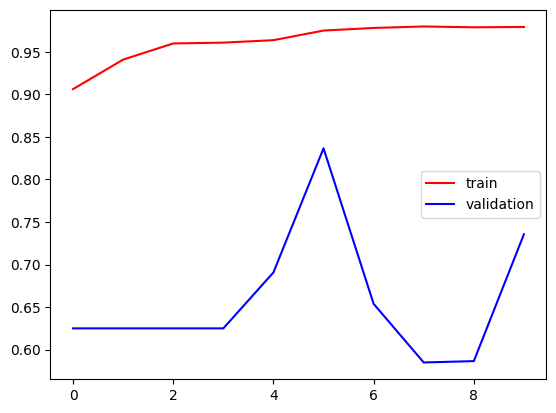

In [44]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [47]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_pneumonia(img_path, model):
    # 1. Load the image and resize it to your model's input size
    # Replace (128, 128) with whatever size you used during training
    img = image.load_img(img_path, target_size=(256, 256))

    # 2. Convert image to array and normalize (0 to 1)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0

    # 3. Add a 'batch' dimension (Model expects [batch_size, height, width, channels])
    img_array = np.expand_dims(img_array, axis=0)

    # 4. Make the prediction
    prediction = model.predict(img_array)

    # 5. Logic for Binary Classification
    # If the output is > 0.5, it's Pneumonia (Label 1)
    if prediction[0][0] > 0.5:
        result = "YES (Pneumonia Detected)"
        confidence = prediction[0][0] * 100
    else:
        result = "NO (Normal Lungs)"
        confidence = (1 - prediction[0][0]) * 100

    print(f"Result: {result}")
    print(f"Confidence: {confidence:.2f}%")

In [48]:
from google.colab import files

# Step 1: Upload the file
uploaded = files.upload()

# Step 2: Run the prediction on the uploaded file
for filename in uploaded.keys():
    predict_pneumonia(filename, model)

Saving pnemonia.png to pnemonia.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Result: YES (Pneumonia Detected)
Confidence: 100.00%
